# LJ Speech Dataset

In [7]:
import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import librosa
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


In [8]:
DATA_DIR = Path('/kaggle/input/datasets/mathurinache/the-lj-speech-dataset/LJSpeech-1.1')
METADATA_PATH = DATA_DIR / "metadata.csv"
WAVS_DIR = DATA_DIR / "wavs"

print(f"Dataset root : {DATA_DIR}")
print(f"Metadata file: {METADATA_PATH}")
print(f"Wavs dir     : {WAVS_DIR} (exists: {WAVS_DIR.exists()})")


Dataset root : /kaggle/input/datasets/mathurinache/the-lj-speech-dataset/LJSpeech-1.1
Metadata file: /kaggle/input/datasets/mathurinache/the-lj-speech-dataset/LJSpeech-1.1/metadata.csv
Wavs dir     : /kaggle/input/datasets/mathurinache/the-lj-speech-dataset/LJSpeech-1.1/wavs (exists: True)


In [9]:
df = pd.read_csv(
    METADATA_PATH,
    sep="|",
    header=None,
    names=["id", "transcription", "normalized_transcription"],
    quoting=3,  
    keep_default_na=False,
    dtype=str,
)

empty_norm = df["normalized_transcription"] == ""
df.loc[empty_norm, "normalized_transcription"] = df.loc[empty_norm, "transcription"]

print(f"Rows              : {len(df):,}")
print(f"Empty normalized  : {empty_norm.sum()}")
print(f"Duplicate ids     : {df['id'].duplicated().sum()}")
df.head()


Rows              : 13,100
Empty normalized  : 0
Duplicate ids     : 0


,id,transcription,normalized_transcription
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...


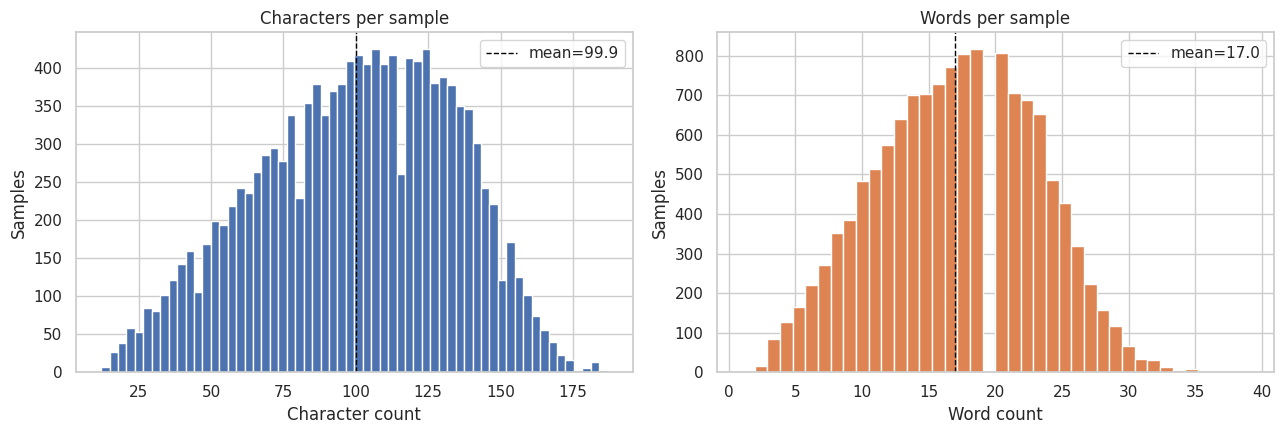

,char_count,word_count
count,13100.000000,13100.000000
mean,99.898779,16.986565
std,33.952214,6.063484
min,12.000000,1.000000
25%,76.000000,13.000000
50%,102.000000,17.000000
75%,126.000000,21.000000
max,187.000000,39.000000


In [10]:
df["char_count"] = df["normalized_transcription"].str.len()
df["word_count"] = df["normalized_transcription"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df["char_count"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(df["char_count"].mean(), color="black", ls="--", lw=1,
                 label=f"mean={df['char_count'].mean():.1f}")
axes[0].set_title("Characters per sample")
axes[0].set_xlabel("Character count")
axes[0].set_ylabel("Samples")
axes[0].legend()

axes[1].hist(df["word_count"], bins=40, color="#DD8452", edgecolor="white")
axes[1].axvline(df["word_count"].mean(), color="black", ls="--", lw=1,
                 label=f"mean={df['word_count'].mean():.1f}")
axes[1].set_title("Words per sample")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Samples")
axes[1].legend()

plt.tight_layout()
plt.show()

df[["char_count", "word_count"]].describe()


In [11]:
all_text = "".join(df["normalized_transcription"])
unique_chars = sorted(set(all_text))

print(f"Unique character count: {len(unique_chars)}")
print("Unique characters:")
print(" ".join(repr(c)[1:-1] for c in unique_chars))



Unique character count: 75
Unique characters:
  ! " ' ( ) , - . : ; ? A B C D E F G H I J K L M N O P Q R S T U V W X Y Z [ ] a b c d e f g h i j k l m n o p q r s t u v w x y z à â è é ê ü ’ “ ”


In [12]:
SAMPLE_SIZE = None    # e.g. 500 for a quick smoke test, None for the full corpus
SILENCE_TOP_DB = 30   # dB below peak amplitude considered "silence" when trimming

ids = df["id"].tolist()
if SAMPLE_SIZE:
    ids = ids[:SAMPLE_SIZE]

records = []
missing = 0
for file_id in tqdm(ids, desc="Scanning wavs"):
    wav_path = WAVS_DIR / f"{file_id}.wav"
    if not wav_path.exists():
        missing += 1
        continue

    audio, sr = sf.read(wav_path, dtype="float32")
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    duration = len(audio) / sr
    _, trim_idx = librosa.effects.trim(audio, top_db=SILENCE_TOP_DB)
    leading_silence = trim_idx[0] / sr
    trailing_silence = (len(audio) - trim_idx[1]) / sr

    records.append({
        "id": file_id,
        "sample_rate": sr,
        "duration": duration,
        "leading_silence": leading_silence,
        "trailing_silence": trailing_silence,
    })

audio_df = pd.DataFrame(records)
print(f"Wav files scanned: {len(audio_df):,} / {len(ids):,} (missing: {missing})")
audio_df.head()


Scanning wavs:   0%|          | 0/13100 [00:00<?, ?it/s]

Wav files scanned: 13,100 / 13,100 (missing: 0)


,id,sample_rate,duration,leading_silence,trailing_silence
0,LJ001-0001,22050,9.655011,0.02322,0.08839
1,LJ001-0002,22050,1.899546,0.00000,0.06517
2,LJ001-0003,22050,9.666621,0.02322,0.07678
3,LJ001-0004,22050,5.138730,0.02322,0.07678
4,LJ001-0005,22050,8.110884,0.00000,0.10000


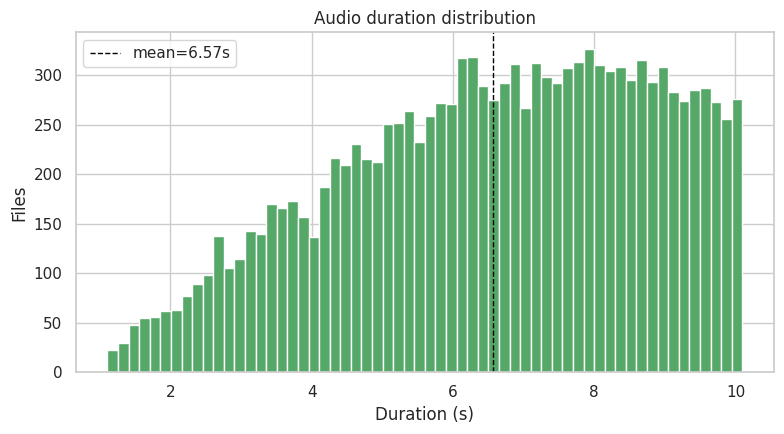

Total corpus duration: 23.92 hours across 13,100 files


count    13100.000000
mean         6.573823
std          2.185431
min          1.110068
25%          4.987800
50%          6.764127
75%          8.389524
max         10.096190
Name: duration, dtype: float64

In [13]:
plt.figure(figsize=(8, 4.5))
plt.hist(audio_df["duration"], bins=60, color="#55A868", edgecolor="white")
plt.axvline(audio_df["duration"].mean(), color="black", ls="--", lw=1,
            label=f"mean={audio_df['duration'].mean():.2f}s")
plt.title("Audio duration distribution")
plt.xlabel("Duration (s)")
plt.ylabel("Files")
plt.legend()
plt.tight_layout()
plt.show()

total_hours = audio_df["duration"].sum() / 3600
print(f"Total corpus duration: {total_hours:.2f} hours across {len(audio_df):,} files")
audio_df["duration"].describe()


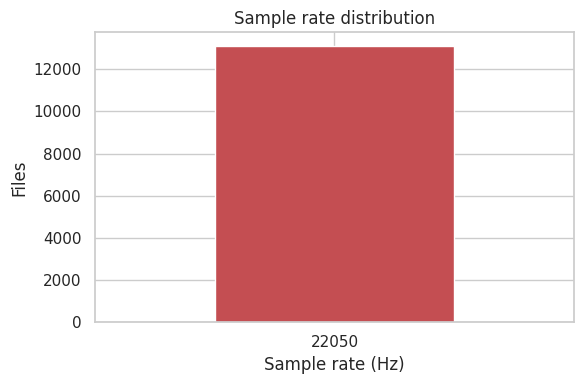

All 13,100 files share a single sample rate: 22050 Hz


In [14]:
sr_counts = audio_df["sample_rate"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sr_counts.plot(kind="bar", color="#C44E52", edgecolor="white")
plt.title("Sample rate distribution")
plt.xlabel("Sample rate (Hz)")
plt.ylabel("Files")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

if len(sr_counts) == 1:
    print(f"All {len(audio_df):,} files share a single sample rate: {sr_counts.index[0]} Hz")
else:
    print("Warning -- multiple sample rates found:")
    print(sr_counts)


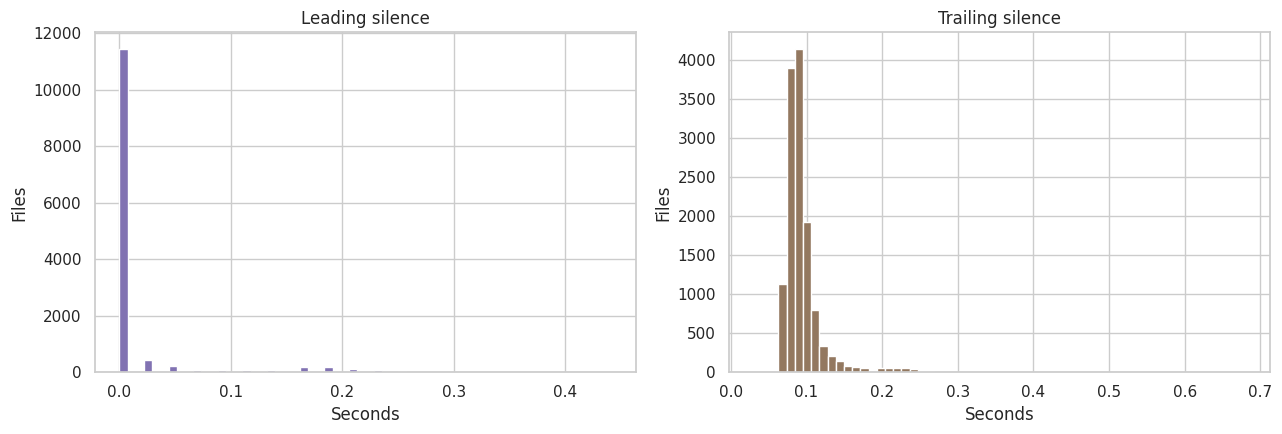

,leading_silence,trailing_silence
count,13100.000000,13100.000000
mean,0.013762,0.092823
std,0.045554,0.028785
min,0.000000,0.030340
25%,0.000000,0.076780
50%,0.000000,0.088390
75%,0.000000,0.100000
max,0.441179,0.680499


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(audio_df["leading_silence"], bins=60, color="#8172B2", edgecolor="white")
axes[0].set_title("Leading silence")
axes[0].set_xlabel("Seconds")
axes[0].set_ylabel("Files")

axes[1].hist(audio_df["trailing_silence"], bins=60, color="#937860", edgecolor="white")
axes[1].set_title("Trailing silence")
axes[1].set_xlabel("Seconds")
axes[1].set_ylabel("Files")

plt.tight_layout()
plt.show()

audio_df[["leading_silence", "trailing_silence"]].describe()


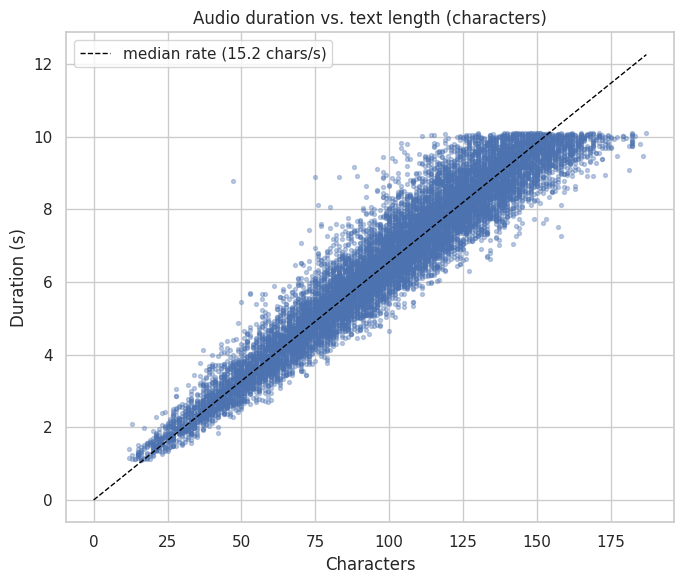

count    13100.000000
mean        15.237915
std          1.582160
min          5.343415
25%         14.241719
50%         15.249465
75%         16.267176
max         22.664644
Name: chars_per_second, dtype: float64

In [16]:
merged = df.merge(audio_df, on="id", how="inner")
merged["chars_per_second"] = merged["char_count"] / merged["duration"]

plt.figure(figsize=(7, 6))
plt.scatter(merged["char_count"], merged["duration"], s=8, alpha=0.35, color="#4C72B0")

median_rate = merged["chars_per_second"].median()
x_ref = np.linspace(0, merged["char_count"].max(), 50)
plt.plot(x_ref, x_ref / median_rate, color="black", ls="--", lw=1,
         label=f"median rate ({median_rate:.1f} chars/s)")

plt.title("Audio duration vs. text length (characters)")
plt.xlabel("Characters")
plt.ylabel("Duration (s)")
plt.legend()
plt.tight_layout()
plt.show()

merged["chars_per_second"].describe()


In [17]:
mean_rate = merged["chars_per_second"].mean()
std_rate = merged["chars_per_second"].std()
outlier_mask = (merged["chars_per_second"] - mean_rate).abs() > 3 * std_rate
outliers = merged.loc[outlier_mask].sort_values("chars_per_second")

print(f"Speaking-rate outliers (>3 std from mean, {mean_rate:.2f} +/- {std_rate:.2f} chars/s): {len(outliers)}")
outliers[["id", "duration", "char_count", "chars_per_second", "normalized_transcription"]]


Speaking-rate outliers (>3 std from mean, 15.24 +/- 1.58 chars/s): 77


,id,duration,char_count,chars_per_second,normalized_transcription
3928,LJ014-0165,8.795873,47,5.343415,and presented by no heathen land under the sun.
8268,LJ031-0024,2.096916,13,6.199580,Gene C. Akin;
9805,LJ037-0193,8.888753,75,8.437629,"S T. W. two inch BBL, unquote, cost twenty-nin..."
12922,LJ050-0101,1.992426,17,8.532311,"Leon F. Czolgosz,"
11284,LJ043-0159,1.400317,12,8.569485,Answer: Yes.
...,...,...,...,...,...
8397,LJ031-0153,4.662721,100,21.446704,The telephone line to Washington was kept open...
9534,LJ036-0140,7.274966,158,21.718315,He gave me a dollar bill and didn't say anythi...
4046,LJ014-0285,2.758685,60,21.749494,and not for the slight offense as it appeared ...
8778,LJ033-0026,2.700635,59,21.846714,There was little conversation between them on ...


In [18]:
summary = {
    "num_text_samples": len(df),
    "num_wav_files_found": len(audio_df),
    "total_audio_hours": round(audio_df["duration"].sum() / 3600, 2),
    "unique_sample_rates_hz": sorted(audio_df["sample_rate"].unique().tolist()),
    "mean_duration_s": round(audio_df["duration"].mean(), 3),
    "mean_char_count": round(df["char_count"].mean(), 1),
    "mean_word_count": round(df["word_count"].mean(), 1),
    "speaker": "Linda Johnson",
}
for k, v in summary.items():
    print(f"{k:>22}: {v}")


      num_text_samples: 13100
   num_wav_files_found: 13100
     total_audio_hours: 23.92
unique_sample_rates_hz: [22050]
       mean_duration_s: 6.574
       mean_char_count: 99.9
       mean_word_count: 17.0
               speaker: Linda Johnson


In [22]:
clean_df = merged.loc[~outlier_mask].reset_index(drop=True)
print(f"Removed {outlier_mask.sum()} speaking-rate outliers (Section 6) -> {len(clean_df):,} / {len(merged):,} samples remain")
clean_df['book_id'] = clean_df['id'].apply(lambda x: x.split('-')[0])

# Get unique books/chapters and shuffle them
unique_books = clean_df['book_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_books)

total_sentences = len(clean_df)
target_ood_count = int(0.03 * total_sentences)

ood_books = []
current_ood_count = 0

# 1. Isolate whole books until we hit exactly ~10% of the dataset
for book in unique_books:
    book_count = len(clean_df[clean_df['book_id'] == book])
    if current_ood_count + book_count <= target_ood_count + 50:  # 50 is a small buffer
        ood_books.append(book)
        current_ood_count += book_count
    if current_ood_count >= target_ood_count:
        break

# 2. The remaining books form our "In-Domain" pool
in_domain_books = [b for b in unique_books if b not in ood_books]

ood_test_df = clean_df[clean_df['book_id'].isin(ood_books)].copy()
in_domain_df = clean_df[clean_df['book_id'].isin(in_domain_books)].copy()

# 3. Randomly shuffle and split the In-Domain pool
in_domain_df = in_domain_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_target = int(0.94 * total_sentences)
val_target = int(0.01 * total_sentences)

train_df = in_domain_df.iloc[:train_target].copy()
val_df = in_domain_df.iloc[train_target : train_target + val_target].copy()
id_test_df = in_domain_df.iloc[train_target + val_target :].copy()

print("--- HYBRID SPLIT RESULTS ---")
print(f"Total Sentences: {total_sentences}")
print(f"Train:                  {len(train_df)} sentences ({len(train_df)/total_sentences:.1%})")
print(f"Val:                    {len(val_df)} sentences ({len(val_df)/total_sentences:.1%})")
print(f"Test (In-Domain):       {len(id_test_df)} sentences ({len(id_test_df)/total_sentences:.1%})")
print(f"Test (Unseen Books):    {len(ood_test_df)} sentences ({len(ood_test_df)/total_sentences:.1%})")

# Verify the isolation worked
train_books_set = set(train_df['book_id'])
ood_test_books_set = set(ood_test_df['book_id'])
overlap = train_books_set.intersection(ood_test_books_set)
print(f"\nBook overlap between Train and Unseen Books Test: {len(overlap)} (Should be 0)")


Removed 77 speaking-rate outliers (Section 6) -> 13,023 / 13,100 samples remain
--- HYBRID SPLIT RESULTS ---
Total Sentences: 13023
Train:                  12241 sentences (94.0%)
Val:                    130 sentences (1.0%)
Test (In-Domain):       318 sentences (2.4%)
Test (Unseen Books):    334 sentences (2.6%)

Book overlap between Train and Unseen Books Test: 0 (Should be 0)


In [23]:
OUTPUT_DIR = Path("/kaggle/working")

id_test_df["domain"] = "in_domain"
ood_test_df["domain"] = "unseen_book"
test_df = pd.concat([id_test_df, ood_test_df], ignore_index=True)

assert len(train_df) + len(val_df) + len(test_df) == len(clean_df)

splits = {
    "train.csv": train_df,
    "val.csv": val_df,
    "test.csv": test_df,
}

for filename, split_df in splits.items():
    out_path = OUTPUT_DIR / filename
    split_df.to_csv(out_path, index=False)
    print(f"Saved {out_path} -- {len(split_df):,} rows")


Saved /kaggle/working/train.csv -- 12,241 rows
Saved /kaggle/working/val.csv -- 130 rows
Saved /kaggle/working/test.csv -- 652 rows


In [24]:
test_df.head()

,id,transcription,normalized_transcription,char_count,word_count,sample_rate,duration,leading_silence,trailing_silence,chars_per_second,book_id,domain
0,LJ016-0138,at a distance from the prison.,at a distance from the prison.,30,6,22050,1.760227,0.00000,0.06517,17.043259,LJ016,in_domain
1,LJ038-0152,Oswald told Fritz that after lunch he went out...,Oswald told Fritz that after lunch he went out...,132,24,22050,9.016463,0.20898,0.10000,14.639888,LJ038,in_domain
2,LJ019-0359,He could in the first place withhold the gover...,He could in the first place withhold the gover...,159,28,22050,9.805941,0.20898,0.07678,16.214660,LJ019,in_domain
3,LJ006-0238,"""There was a disturbance in the transport yard...","""There was a disturbance in the transport yard...",96,16,22050,4.813651,0.00000,0.07678,19.943283,LJ006,in_domain
4,LJ048-0289,"However, there is no evidence that these men f...","However, there is no evidence that these men f...",136,24,22050,9.794331,0.02322,0.08839,13.885583,LJ048,in_domain
